Este notebook contém os testes para implementação das soluções da equação de Poisson 1D e 3D

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import solve, norm
import plotly.graph_objects as go
from scipy.interpolate import RegularGridInterpolator

N = 21 por direção  |  Pontos da Malha Numérica = 9261
Resíduo interior L∞: 1.876e-11
Potencial máximo: 1.922e+01 V
Potencial mínimo: -6.756e-12 V


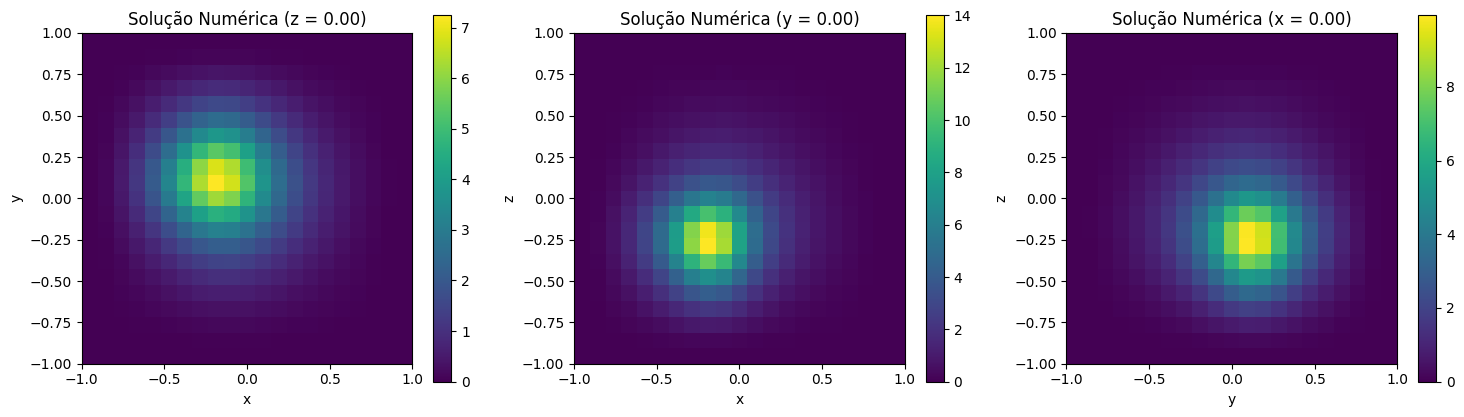

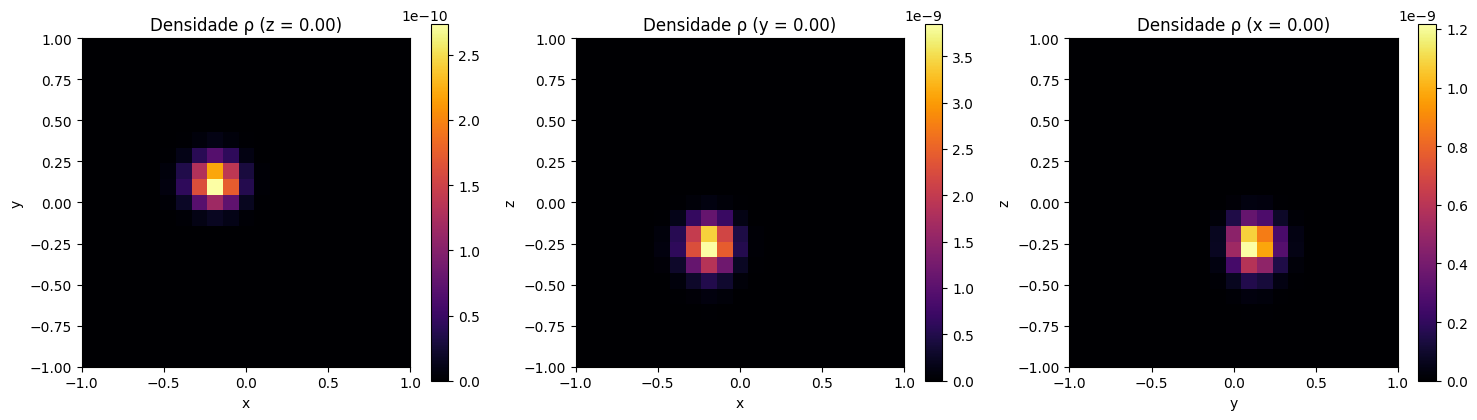

In [3]:
# =============================================================
# Equação de Poisson 3D — Método Espectral Galerkin-colocação
# ∇²u = f(x,y,z),  u = u_bc em ∂Ω
# Domínio: [-1,1]^3
# Densidade de carga: gaussiana deslocada
#   ρ(x,y,z) = A exp(-[(x-cx)² + (y-cy)² + (z-cz)²] / (2σ²))
#   f = -ρ/ε₀
# =============================================================

# -------------------------------------------------------------
# parâmetros e pontos de colocação em cada direção
# -------------------------------------------------------------
N              = 20
xmin, xmax     = -1.0, 1.0
ymin, ymax     = -1.0, 1.0
zmin, zmax     = -1.0, 1.0

j    = np.arange(N + 1)
xi   = np.cos(np.pi * j / N)

x    = 0.5 * (xmin + xmax) + 0.5 * (xmax - xmin) * xi
y    = 0.5 * (ymin + ymax) + 0.5 * (ymax - ymin) * xi
z    = 0.5 * (zmin + zmax) + 0.5 * (zmax - zmin) * xi

Xg, Yg, Zg = np.meshgrid(x, y, z, indexing="ij")

# -------------------------------------------------------------
# matriz de diferenciação espectral em 1D
# -------------------------------------------------------------
c       = np.ones(N + 1)
c[0]    = 2.0
c[-1]   = 2.0
c       = c * ((-1.0) ** j)

Xm      = np.tile(xi, (N + 1, 1)).T
dXm     = Xm - Xm.T
D_ref   = np.outer(c, 1.0 / c) / (dXm + np.eye(N + 1))
D_ref  -= np.diag(D_ref.sum(axis=1))

Dx      = (2.0 / (xmax - xmin)) * D_ref
Dy      = (2.0 / (ymax - ymin)) * D_ref
Dz      = (2.0 / (zmax - zmin)) * D_ref

D2x     = Dx @ Dx
D2y     = Dy @ Dy
D2z     = Dz @ Dz

# -------------------------------------------------------------
# laplaciano 3D
# -------------------------------------------------------------
I       = np.eye(N + 1)
Lap     = (np.kron(np.kron(D2x, I), I)
         + np.kron(np.kron(I, D2y), I)
         + np.kron(np.kron(I, I), D2z))

# -------------------------------------------------------------
# densidade de carga gaussiana e termo fonte
# -------------------------------------------------------------
eps0   = 8.8541878128e-12
A      = 1.0e-8         # amplitude em C/m³
sigma  = 0.15           # largura em m
cx, cy, cz = 0.3, -0.2, 0.4

rho = A * np.exp(
    -((Xg - cx)**2 + (Yg - cy)**2 + (Zg - cz)**2) / (2.0 * sigma**2)
)

f = -rho / eps0

f_flat = f.ravel(order="F")

# -------------------------------------------------------------
# condições de contorno de Dirichlet homogêneas (u = 0 em ∂Ω)
# -------------------------------------------------------------
A_mat = Lap.copy()
rhs   = f_flat.copy()

mask_bc = np.zeros((N + 1, N + 1, N + 1), dtype=bool)
mask_bc[0, :, :] = True;  mask_bc[-1, :, :] = True
mask_bc[:, 0, :] = True;  mask_bc[:, -1, :] = True
mask_bc[:, :, 0] = True;  mask_bc[:, :, -1] = True
idx_bc = np.where(mask_bc.ravel(order="F"))[0]

A_mat[idx_bc, :]      = 0.0
A_mat[idx_bc, idx_bc] = 1.0
rhs[idx_bc]           = 0.0

# -------------------------------------------------------------
# solução do sistema linear
# -------------------------------------------------------------
u_flat = solve(A_mat, rhs)
u      = u_flat.reshape((N + 1, N + 1, N + 1), order="F")

# -------------------------------------------------------------
# diagnóstico
# -------------------------------------------------------------
residuo = norm((Lap @ u_flat - f_flat)[~mask_bc.ravel(order="F")], ord=np.inf)

print("=" * 55)
print(f"N = {N + 1} por direção  |  Pontos da Malha Numérica = {(N+1)**3}")
print(f"Resíduo interior L∞: {residuo:.3e}")
print(f"Potencial máximo: {u.max():.3e} V")
print(f"Potencial mínimo: {u.min():.3e} V")
print("=" * 55)

# -------------------------------------------------------------
# visualização da solução numérica em cortes centrais
# -------------------------------------------------------------
k_mid = N // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

im0 = axes[0].imshow(u[:, :, k_mid].T, origin="lower",
                     extent=[xmin, xmax, ymin, ymax], cmap="viridis")
axes[0].set_title(f"Solução Numérica (z = {z[k_mid]:.2f})")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(u[:, k_mid, :].T, origin="lower",
                     extent=[xmin, xmax, zmin, zmax], cmap="viridis")
axes[1].set_title(f"Solução Numérica (y = {y[k_mid]:.2f})")
axes[1].set_xlabel("x"); axes[1].set_ylabel("z")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(u[k_mid, :, :].T, origin="lower",
                     extent=[ymin, ymax, zmin, zmax], cmap="viridis")
axes[2].set_title(f"Solução Numérica (x = {x[k_mid]:.2f})")
axes[2].set_xlabel("y"); axes[2].set_ylabel("z")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout(); plt.show()

# -----------------------------------------------------------------------------
# visualização do campo u(x,y,z) com cortes apenas na direção z
# -----------------------------------------------------------------------------

Ng = 60
xg = np.linspace(xmin, xmax, Ng)
yg = np.linspace(ymin, ymax, Ng)
zg = np.linspace(zmin, zmax, Ng)
Xgr, Ygr, Zgr = np.meshgrid(xg, yg, zg, indexing="ij")

interp_u = RegularGridInterpolator((x, y, z), u, method="linear",
                                   bounds_error=False, fill_value=0.0)
Ugrid = interp_u(np.stack([Xgr.ravel(), Ygr.ravel(), Zgr.ravel()], axis=-1)
                 ).reshape(Ng, Ng, Ng)

# níveis de z nos quais queremos ver o potencial no plano xy
z_levels = [-0.7, -0.35, 0.0, 0.35, 0.7]
kz_list  = [int(round((zl - zmin) / (zmax - zmin) * (Ng - 1))) for zl in z_levels]

fig = go.Figure()

for i, kz in enumerate(kz_list):
    fig.add_trace(go.Surface(
        x=Xgr[:, :, kz],
        y=Ygr[:, :, kz],
        z=np.full((Ng, Ng), zg[kz]),
        surfacecolor=Ugrid[:, :, kz],
        colorscale="Viridis",
        cmin=Ugrid.min(), cmax=Ugrid.max(),
        showscale=(i == len(kz_list) - 1),
        colorbar=dict(title="u(x,y)", x=1.02) if i == len(kz_list) - 1 else None,
        opacity=0.95,
        name=f"z = {zg[kz]:.2f}",
    ))

fig.update_layout(
    title=f"Solução da Equação de Poisson 3D (N={N + 1})",
    scene=dict(
        xaxis_title="x", yaxis_title="y", zaxis_title="z",
        xaxis=dict(range=[xmin, xmax]),
        yaxis=dict(range=[ymin, ymax]),
        zaxis=dict(range=[zmin, zmax]),
        aspectmode="cube",
    ),
    width=850, height=750,
)

fig.show()

# -------------------------------------------------------------
# visualização da densidade de carga gaussiana
# -------------------------------------------------------------
fig_rho, axes_rho = plt.subplots(1, 3, figsize=(15, 4.2))

im0 = axes_rho[0].imshow(rho[:, :, k_mid].T, origin="lower",
                         extent=[xmin, xmax, ymin, ymax], cmap="inferno")
axes_rho[0].set_title(f"Densidade ρ (z = {z[k_mid]:.2f})")
axes_rho[0].set_xlabel("x"); axes_rho[0].set_ylabel("y")
plt.colorbar(im0, ax=axes_rho[0])

im1 = axes_rho[1].imshow(rho[:, k_mid, :].T, origin="lower",
                         extent=[xmin, xmax, zmin, zmax], cmap="inferno")
axes_rho[1].set_title(f"Densidade ρ (y = {y[k_mid]:.2f})")
axes_rho[1].set_xlabel("x"); axes_rho[1].set_ylabel("z")
plt.colorbar(im1, ax=axes_rho[1])

im2 = axes_rho[2].imshow(rho[k_mid, :, :].T, origin="lower",
                         extent=[ymin, ymax, zmin, zmax], cmap="inferno")
axes_rho[2].set_title(f"Densidade ρ (x = {x[k_mid]:.2f})")
axes_rho[2].set_xlabel("y"); axes_rho[2].set_ylabel("z")
plt.colorbar(im2, ax=axes_rho[2])

plt.tight_layout(); plt.show()